# Experiment Results Analysis

Interactive exploration of agentic architecture comparison results.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load results
results_path = Path("../results/results.jsonl")
records = [json.loads(line) for line in results_path.read_text().strip().splitlines()]
df = pd.DataFrame(records)

# Flatten token_usage
usage_df = pd.json_normalize(df["token_usage"])
usage_df.columns = [f"token_{c}" for c in usage_df.columns]
df = pd.concat([df.drop(columns=["token_usage"]), usage_df], axis=1)

print(f"Loaded {len(df)} results")
df.head()

Loaded 60 results


,architecture,domain,difficulty,task_id,run_id,success,score,runtime_seconds,num_iterations,num_llm_calls,final_answer,evaluation_details,error,token_prompt_tokens,token_completion_tokens,token_total_tokens,token_llm_call_count
0,level1,gridworld,easy,0,0,True,1.0,14.813,9,9,\nDONE,"{'reached_goal': True, 'steps_taken': 8, 'fina...",None,8857,1356,10213,9
1,level1,gridworld,easy,0,1,True,1.0,14.925,7,7,\nDONE,"{'reached_goal': True, 'steps_taken': 6, 'fina...",None,6402,1393,7795,7
2,level1,gridworld,easy,0,2,True,1.0,15.036,10,10,\nDONE,"{'reached_goal': True, 'steps_taken': 9, 'fina...",None,10994,1357,12351,10
3,level1,gridworld,easy,0,3,False,0.0,17.261,0,13,,{},GraphRecursionError: Recursion limit of 25 rea...,14350,1555,15905,13
4,level1,gridworld,easy,0,4,True,1.0,9.226,10,10,\nDONE,"{'reached_goal': True, 'steps_taken': 9, 'fina...",None,9037,798,9835,10


In [2]:
# Summary statistics
summary = df.groupby(["architecture", "domain", "difficulty"]).agg(
    n=("success", "count"),
    success_rate=("success", "mean"),
    avg_score=("score", "mean"),
    std_score=("score", "std"),
    avg_runtime=("runtime_seconds", "mean"),
    avg_tokens=("token_total_tokens", "mean"),
    avg_llm_calls=("num_llm_calls", "mean"),
).round(3)
summary

n  success_rate  avg_score  std_score  \
architecture domain    difficulty                                           
level1       gridworld easy        15           0.6        0.6      0.507   
                       hard        15           0.0        0.0      0.000   
level2a      gridworld easy        15           1.0        1.0      0.000   
                       hard        15           0.0        0.0      0.000   

                                   avg_runtime  avg_tokens  avg_llm_calls  
architecture domain    difficulty                                          
level1       gridworld easy             17.255   12043.600         10.200  
                       hard             13.206   20323.400         13.000  
level2a      gridworld easy             29.385   10923.933          9.333  
                       hard             53.919   22673.400         13.000

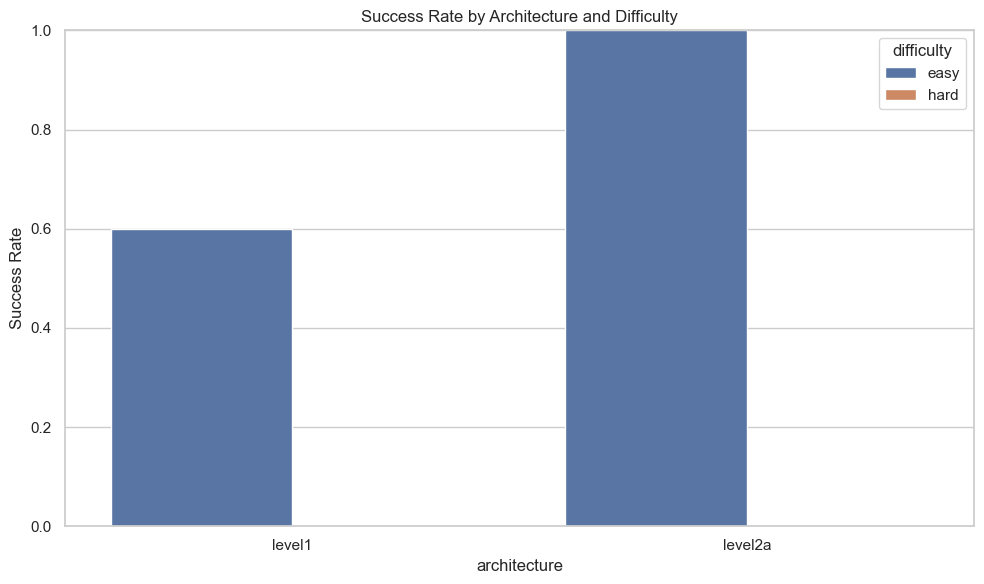

In [3]:
# Success rate comparison
fig, ax = plt.subplots(figsize=(10, 6))
grouped = df.groupby(["architecture", "difficulty"])["success"].mean().reset_index()
sns.barplot(data=grouped, x="architecture", y="success", hue="difficulty", ax=ax)
ax.set_title("Success Rate by Architecture and Difficulty")
ax.set_ylabel("Success Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

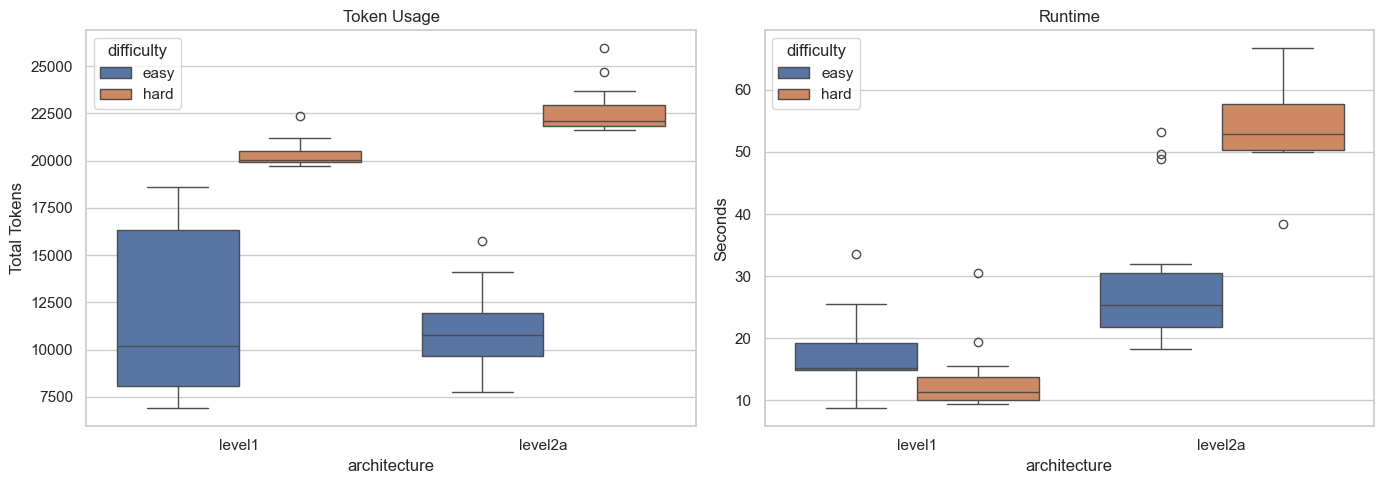

In [4]:
# Token usage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="architecture", y="token_total_tokens", hue="difficulty", ax=axes[0])
axes[0].set_title("Token Usage")
axes[0].set_ylabel("Total Tokens")

sns.boxplot(data=df, x="architecture", y="runtime_seconds", hue="difficulty", ax=axes[1])
axes[1].set_title("Runtime")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

In [5]:
# Error analysis
errors = df[df["error"].notna()]
if len(errors) > 0:
    print(f"{len(errors)} runs with errors:")
    print(errors[["architecture", "difficulty", "task_id", "error"]].to_string())
else:
    print("No errors encountered.")

36 runs with errors:
   architecture difficulty  task_id                                                                                                                                                                                                                                                                     error
3        level1       easy        0  GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.\nFor troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT
6        level1       easy        1  GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.\nFor troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT
7        level1       easy        1  GraphRecursionError: Recursion limit